In [19]:
import joblib
import pandas as pd
import dice_ml
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


phase1_neg = Path("../results/phase1/0")
phase1_pos = Path("../results/phase1/1")

pipelineLR = joblib.load("../../models/a-lr.pkl")
pipelineEN = joblib.load("../../models/a-en.pkl")
data = pd.read_pickle("../../data/a.pkl.gz")

with open("../../models/a-lr.json") as f:
    setup = json.load(f)
    y_values = setup["experiment_setup"]["y"]

df = data.loc[:, [col for col in data.columns if "_id" not in col]]

df["outcome"] = y_values

C:\Users\jamie\Documents\GitHub\cfe-vis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KNNImputer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\jamie\Documents\GitHub\cfe-vis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\jamie\Documents\GitHub\cfe-vis\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version

In [20]:
df.head()


,rhf,acpa,IgG_cit,IgG_arg_ctl,IgG_car,IgG_ace,IgG_lys_ctl,IgA_cit,IgA_arg_ctl,IgA_car,IgA_ace,IgA_lys_ctl,outcome
0,2.772589,5.831882,8.517073,2.028148,2.433613,1.526056,4.060443,1.722767,2.595255,0.641854,1.131402,0.641854,0
1,3.737670,5.337538,6.854882,1.887070,1.435085,1.902108,1.131402,0.788457,3.122365,1.609438,0.916291,1.098612,1
2,3.218876,0.875469,0.336472,1.887070,1.410987,2.332144,1.945910,1.386294,1.667707,1.609438,0.000000,1.098612,0
3,3.496508,4.795791,6.862339,1.960095,0.741937,2.332144,1.386294,0.916291,1.360977,1.360977,0.000000,1.223775,1
4,3.806662,4.969813,6.746412,2.397895,2.140066,2.541602,2.028148,1.757858,1.360977,2.302585,1.458615,2.332144,0


In [21]:
# Generate dice data object
dice_data = dice_ml.Data(
    dataframe=df,
    continuous_features=[col for col in df.columns if col != "outcome"],
    outcome_name="outcome"
)

# generate dice model objects
dice_modelLR = dice_ml.Model(
    model=pipelineLR,
    backend="sklearn"
)

dice_modelEN = dice_ml.Model(
    model=pipelineEN,
    backend="sklearn"
)

# create explainers

expLR = dice_ml.Dice(dice_data, dice_modelLR, method="genetic")

expEN = dice_ml.Dice(dice_data, dice_modelEN, method="genetic")

In [22]:
# drop target
query = df.drop(columns=["outcome"]).iloc[[0]]


# generate counterfactuals
counterfactualsLR = expLR.generate_counterfactuals(
    query_instances=query,
    total_CFs=3,
    desired_class="opposite"
)

counterfactualsEN = expEN.generate_counterfactuals(
    query_instances=query,
    total_CFs=3,
    desired_class="opposite"
)

100%|██████████| 1/1 [00:00<00:00, 15.79it/s]


In [23]:
print("LR")
counterfactualsLR.visualize_as_dataframe(show_only_changes=True)
print("EN")
counterfactualsEN.visualize_as_dataframe(show_only_changes=True)

LR
Query instance (original outcome : 0)


,rhf,acpa,IgG_cit,IgG_arg_ctl,IgG_car,IgG_ace,IgG_lys_ctl,IgA_cit,IgA_arg_ctl,IgA_car,IgA_ace,IgA_lys_ctl,outcome
0,2.772589,5.831882,8.517074,2.028148,2.433613,1.526056,4.060443,1.722767,2.595255,0.641854,1.131402,0.641854,0



Diverse Counterfactual set (new outcome: 1)


,rhf,acpa,IgG_cit,IgG_arg_ctl,IgG_car,IgG_ace,IgG_lys_ctl,IgA_cit,IgA_arg_ctl,IgA_car,IgA_ace,IgA_lys_ctl,outcome
0,3.7,-,4.81299686,1.1939225,3.2108436,2.3887627,2.442347,-,1.3862944,1.987874,1.6,2.0541236,1.0
0,0.0,-,4.63763714,1.8245493,0.0,2.3321438,1.1314021,0.7884573,2.4765384,-,0.0,2.0668628,1.0
0,3.5,-,4.66343927,0.7419373,0.0,2.9957323,2.2925348,0.7884573,2.6318889,-,0.0,2.0668628,1.0


EN
Query instance (original outcome : 0)


,rhf,acpa,IgG_cit,IgG_arg_ctl,IgG_car,IgG_ace,IgG_lys_ctl,IgA_cit,IgA_arg_ctl,IgA_car,IgA_ace,IgA_lys_ctl,outcome
0,2.772589,5.831882,8.517074,2.028148,2.433613,1.526056,4.060443,1.722767,2.595255,0.641854,1.131402,0.641854,0



Diverse Counterfactual set (new outcome: 1)


,rhf,acpa,IgG_cit,IgG_arg_ctl,IgG_car,IgG_ace,IgG_lys_ctl,IgA_cit,IgA_arg_ctl,IgA_car,IgA_ace,IgA_lys_ctl,outcome
0,0.0,-,4.81299686,2.0412204,3.2108436,2.1282318,2.442347,-,1.3862944,2.833213,2.1,2.0541236,1.0
0,0.0,-,4.81299686,2.0412204,3.2108436,0.7419373,2.442347,-,0.2623643,2.833213,0.5,0.0,1.0
0,3.9,-,4.63763714,2.74084,1.9315214,0.7419373,2.9496884,1.6486586,2.4765384,1.94591,0.5,1.7227666,1.0


In [24]:
import os, pickle

feature_cols = [col for col in df.columns if col != "outcome"]
X = df[feature_cols]

CACHE_LR = "../data/cfe_batch_lr.pkl"
CACHE_EN = "../data/cfe_batch_en.pkl"

# ── NEW: helper to load cache ──
def load_cache(cache_path):
    if os.path.exists(cache_path):
        try:
            with open(cache_path, "rb") as f:
                data = pickle.load(f)
            print(f"Loaded cache from {cache_path} ({sum(r is not None for r in data)}/{len(data)} succeeded)")
            return data
        except Exception as e:
            print(f"Cache {cache_path} exists but failed to load: {e}")
    return None

def generate_batch_cfe(explainer, X, feature_cols, cache_path, total_CFs=3):
    results = []
    for i in range(len(X)):
        try:
            cfe = explainer.generate_counterfactuals(
                query_instances=X.iloc[[i]],
                total_CFs=total_CFs,
                desired_class="opposite"
            )
            cf_df = cfe.cf_examples_list[0].final_cfs_df

            if cf_df is not None and len(cf_df) > 0:
                # Store ALL counterfactuals as a list of arrays, not just the first
                all_cfs = [row.values for _, row in cf_df[feature_cols].iterrows()]
                results.append(all_cfs)
            else:
                results.append(None)
        except Exception as e:
            print(f"  Patient {i}: failed ({e})")
            results.append(None)

    with open(cache_path, "wb") as f:
        pickle.dump(results, f)
    return results


cfe_lr = load_cache(CACHE_LR)
if cfe_lr is None:
    print("Generating LR counterfactuals (this may take several minutes)...")
    cfe_lr = generate_batch_cfe(expLR, X, feature_cols, CACHE_LR)
    print(f"Done. {sum(r is not None for r in cfe_lr)}/{len(cfe_lr)} succeeded.")

cfe_en = load_cache(CACHE_EN)
if cfe_en is None:
    print("\nGenerating EN counterfactuals...")
    cfe_en = generate_batch_cfe(expEN, X, feature_cols, CACHE_EN)
    print(f"Done. {sum(r is not None for r in cfe_en)}/{len(cfe_en)} succeeded.")

Loaded cache from ../data/cfe_batch_lr.pkl (114/114 succeeded)
Loaded cache from ../data/cfe_batch_en.pkl (114/114 succeeded)


In [25]:
def compute_normalised_deltas(cfe_results, X, feature_cols, model_name):
    """
    Transform raw counterfactual results into normalised proportional deltas.

    Parameters:
        cfe_results: list where each entry is either None or a list of numpy arrays
                     (one array per counterfactual, each containing feature values)
        X: DataFrame of original patient features
        feature_cols: list of feature column names
        model_name: string label for this model

    Returns:
        DataFrame where each row is one counterfactual with normalised deltas
    """

    feature_ranges = X[feature_cols].max().values - X[feature_cols].min().values

    # Avoid division by zero for any constant features
    feature_ranges[feature_ranges == 0] = np.nan

    rows = []
    for patient_idx, cfe_list in enumerate(cfe_results):
        if cfe_list is None:
            continue

        # Original patient's feature values
        original = X[feature_cols].iloc[patient_idx].values

        # Loop through each counterfactual (now we have all 3, not just the first)
        for cf_idx, cf_values in enumerate(cfe_list):
            # Raw delta â€” same subtraction your compute_avg_deltas does
            raw_delta = cf_values - original

            # Normalised delta â€” proportion of the feature's total range
            # A value of 0.15 means "shifted by 15% of this feature's range"
            normalised_delta = raw_delta / feature_ranges

            row = {
                "patient_idx": patient_idx,
                "model": model_name,
                "cf_number": cf_idx,
            }
            for i, feature in enumerate(feature_cols):
                row[f"{feature}_raw"] = raw_delta[i]       # keep raw deltas for stepping down
                row[f"{feature}_norm"] = normalised_delta[i] # normalised deltas for the abstract view

            rows.append(row)

    return pd.DataFrame(rows)

In [26]:
deltas_lr = compute_normalised_deltas(cfe_lr, X, feature_cols, "logistic_regression")
deltas_en = compute_normalised_deltas(cfe_en, X, feature_cols, "elastic_net")

# Combine into one DataFrame for easy filtering in Dash
all_deltas = pd.concat([deltas_lr, deltas_en], ignore_index=True)

all_deltas.head()

,patient_idx,model,cf_number,rhf_raw,rhf_norm,acpa_raw,acpa_norm,IgG_cit_raw,IgG_cit_norm,IgG_arg_ctl_raw,...,IgA_cit_raw,IgA_cit_norm,IgA_arg_ctl_raw,IgA_arg_ctl_norm,IgA_car_raw,IgA_car_norm,IgA_ace_raw,IgA_ace_norm,IgA_lys_ctl_raw,IgA_lys_ctl_norm
0,0,logistic_regression,0,0.927411,0.147492,2.271648e-08,3.895223e-09,-3.704076,-0.426699,-8.342257e-01,...,2.258896e-09,3.138890e-10,-1.208960,-0.367772,1.346020e+00,2.821968e-01,0.468598,0.084789,1.412270e+00,3.911110e-01
1,0,logistic_regression,1,0.527411,0.083878,2.271648e-08,3.895223e-09,-3.879436,-0.446899,7.126918e-01,...,-3.364722e-01,-4.675509e-02,-0.118716,-0.036114,1.690290e+00,3.543740e-01,-0.631402,-0.114247,1.080913e+00,2.993457e-01
2,0,logistic_regression,2,1.927411,0.306529,2.271648e-08,3.895223e-09,-0.962424,-0.110868,3.136575e-01,...,-3.617900e-01,-5.027317e-02,-0.635160,-0.193219,7.444401e-01,1.560739e-01,-1.131402,-0.204718,8.167612e-01,2.261921e-01
3,1,logistic_regression,0,-0.537670,-0.085509,-4.462069e+00,-7.651165e-01,-6.518410,-0.750901,5.096762e-08,...,5.978370e-01,8.307351e-02,-1.454658,-0.442515,8.756590e-08,1.835843e-08,-0.916291,-0.165795,1.133189e-08,3.138230e-09
4,1,logistic_regression,1,-0.537670,-0.085509,-4.462069e+00,-7.651165e-01,-5.328825,-0.613865,5.096762e-08,...,-6.036427e-08,-8.388025e-09,-1.454658,-0.442515,-9.675839e-01,-2.028566e-01,-0.916291,-0.165795,1.133189e-08,3.138230e-09


In [27]:
bg_color = "#2b2b2b"
text_color = "#d4d4d4"

norm_cols = [col for col in all_deltas.columns if col.endswith("_norm")]


def style_ax(ax):
    ax.set_facecolor(bg_color)
    ax.tick_params(colors=text_color)
    for spine in ax.spines.values():
        spine.set_color("#555555")


def style_cbar(cbar, label):
    cbar.set_label(label, color=text_color)
    cbar.ax.tick_params(labelcolor=text_color, color=text_color)
    cbar.outline.set_edgecolor("#555555")

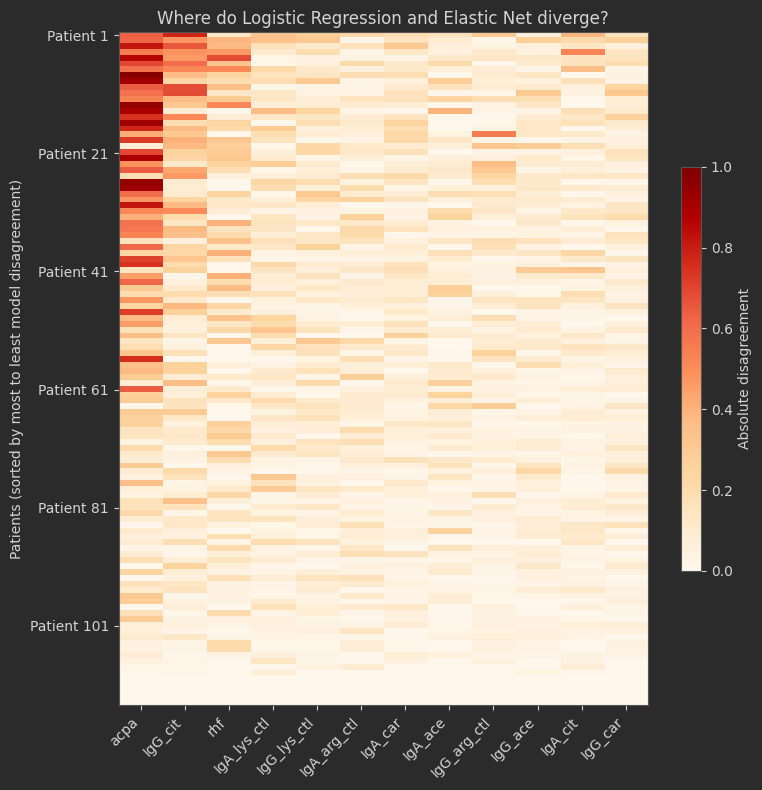

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(bg_color)

lr_avg = (all_deltas[all_deltas["model"] == "logistic_regression"]
          .groupby("patient_idx")[norm_cols].mean())
en_avg = (all_deltas[all_deltas["model"] == "elastic_net"]
          .groupby("patient_idx")[norm_cols].mean())

shared_patients = lr_avg.index.intersection(en_avg.index)
lr_avg = lr_avg.loc[shared_patients]
en_avg = en_avg.loc[shared_patients]

divergence = (en_avg - lr_avg).abs()

# Sort columns by total disagreement
col_order = divergence.sum().sort_values(ascending=False).index
divergence = divergence[col_order]
feature_labels = [col.replace("_norm", "") for col in col_order]

divergence = divergence.loc[divergence.sum(axis=1).sort_values(ascending=False).index]

im = ax.imshow(
    divergence.values,
    aspect="auto",
    cmap="OrRd",
    vmin=0, vmax=1
)

ax.set_xticks(range(len(feature_labels)))
ax.set_xticklabels(feature_labels, rotation=45, ha="right", color=text_color)

# Label every xth patient to keep it readable without clutter
y_ticks = range(0, len(divergence), 20)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"Patient {i+1}" for i in y_ticks], color=text_color)
ax.set_ylabel("Patients (sorted by most to least model disagreement)", color=text_color)

ax.set_title("Where do Logistic Regression and Elastic Net diverge?", color=text_color)

style_ax(ax)

cbar = plt.colorbar(im, ax=ax, label="Absolute disagreement", shrink=0.6)
style_cbar(cbar, "Absolute disagreement")

plt.tight_layout()
fig.savefig(phase1_pos / "heatmap_divergence.png", dpi=300, pad_inches=0.3, facecolor=fig.get_facecolor())
plt.show()

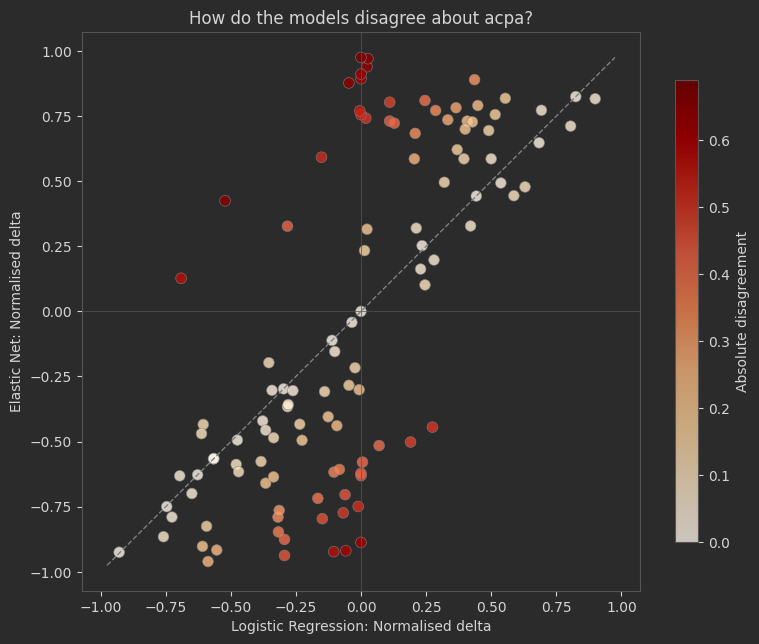

In [29]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(bg_color)

norm_col = "acpa_norm"

lr_deltas = (all_deltas[all_deltas["model"] == "logistic_regression"]
             .groupby("patient_idx")[norm_col].mean())
en_deltas = (all_deltas[all_deltas["model"] == "elastic_net"]
             .groupby("patient_idx")[norm_col].mean())

shared = lr_deltas.index.intersection(en_deltas.index)
lr_vals = lr_deltas.loc[shared].values
en_vals = en_deltas.loc[shared].values

distance_from_diagonal = np.abs(en_vals - lr_vals) / np.sqrt(2)

cmap = plt.cm.OrRd

sc = ax.scatter(
    lr_vals, en_vals,
    c=distance_from_diagonal,
    cmap=cmap,
    vmin=0, vmax=distance_from_diagonal.max(),  # ── NEW: vmin/vmax inline, replaces norm= ──
    s=60,
    alpha=0.8,
    edgecolors="grey",
    linewidth=0.5
)

max_val = np.abs(np.concatenate([lr_vals, en_vals])).max()

ax.plot([-max_val, max_val], [-max_val, max_val],
        color="grey", linestyle="--", linewidth=1)

ax.axhline(y=0, color="#555555", linewidth=0.5)
ax.axvline(x=0, color="#555555", linewidth=0.5)

ax.set_xlabel("Logistic Regression: Normalised delta", color=text_color)
ax.set_ylabel("Elastic Net: Normalised delta", color=text_color)
ax.set_title("How do the models disagree about acpa?", color=text_color)
ax.set_aspect("equal")

style_ax(ax)

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
style_cbar(cbar, "Absolute disagreement")

plt.tight_layout()
fig.savefig(phase1_pos / "scatter_model_disagreement.png", dpi=300, pad_inches=0.3, facecolor=fig.get_facecolor())
plt.show()

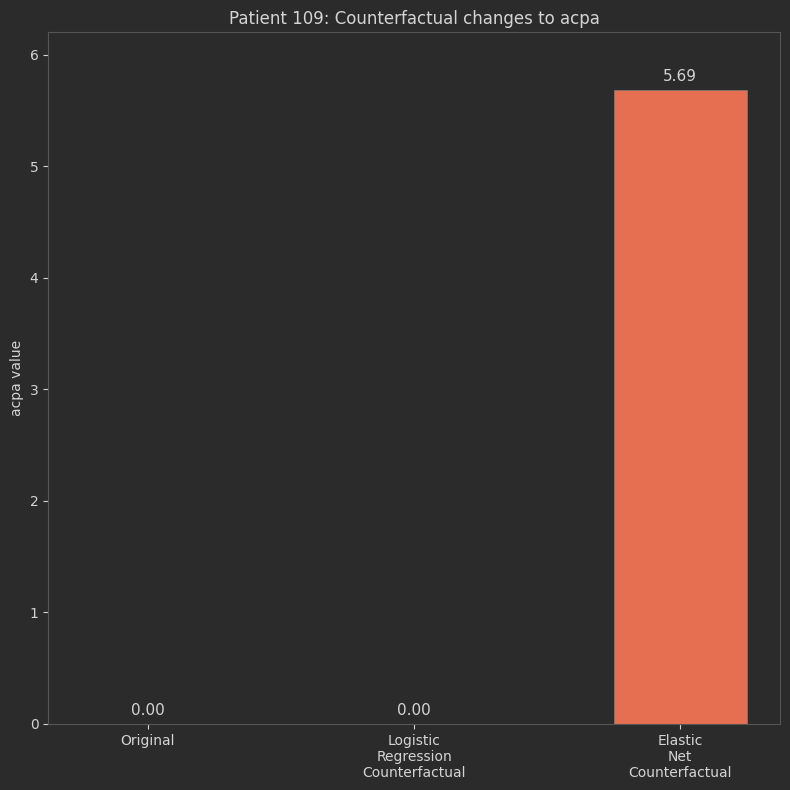

In [30]:
patient = 109

original_val = X["acpa"].iloc[patient]

lr_cf_val = original_val + (all_deltas[
    (all_deltas["patient_idx"] == patient) &
    (all_deltas["model"] == "logistic_regression")
]["acpa_raw"].mean())

en_cf_val = original_val + (all_deltas[
    (all_deltas["patient_idx"] == patient) &
    (all_deltas["model"] == "elastic_net")
]["acpa_raw"].mean())


fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor(bg_color)

values = [original_val, lr_cf_val, en_cf_val]

bars = ax.bar(
    ["Original", "Logistic\nRegression\nCounterfactual", "Elastic\nNet\nCounterfactual"],
    values,  # ── OLD: [original_val, lr_cf_val, en_cf_val] ──
    color=["#d4d4d4", "#2a9d8f", "#e76f51"],
    width=0.5,
    edgecolor="grey",
    linewidth=0.5
)

ax.bar_label(bars, labels=[f"{v:.2f}" for v in values], padding=4, color=text_color, fontsize=11)

ax.set_ylim(0, 6.2)
ax.set_yticks(np.arange(0, 6.5, 1.0))
ax.set_ylabel("acpa value", color=text_color)
ax.set_title(f"Patient {patient}: Counterfactual changes to acpa", color=text_color)

style_ax(ax)

plt.tight_layout()
fig.savefig(phase1_pos / "bar_counterfactual.png", dpi=300, pad_inches=0.3, facecolor=fig.get_facecolor())
plt.show()

In [31]:
# Distance from diagonal for each patient 
acpa_lr = (all_deltas[all_deltas["model"] == "logistic_regression"]
           .groupby("patient_idx")["acpa_norm"].mean())
acpa_en = (all_deltas[all_deltas["model"] == "elastic_net"]
           .groupby("patient_idx")["acpa_norm"].mean())

disagreement = (acpa_en - acpa_lr).abs().sort_values(ascending=False)
print(disagreement.head(10))

patient_idx
109    0.975126
99     0.946772
81     0.943547
89     0.923596
65     0.916376
68     0.911108
18     0.893277
74     0.887167
97     0.861125
83     0.818012
Name: acpa_norm, dtype: float64
